# Comparison across methods

In [ ]:
#init
%load_ext autoreload
%autoreload 2

import lib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time




# Model parameters
S0, K = 100, 100     # Initial stock price and strike
r = 0.05             # Risk-free rate
sigma = 0.3          # Volatility
gamma = 1.2          # CEV parameter
T = 1.0              # Time to maturity
M = 252              # Number of time steps (daily)

# Create simulation instance
sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M)

# Set simulation parameters
#N = 2**20            # Number of paths (power of 2 for QMC)
batches = 32          # Number of batches/scrambles 32

out_dir = '../Graphs'
dir_Tables = '../Tables'
os.makedirs(out_dir, exist_ok=True)
os.makedirs(dir_Tables, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# paste into a notebook cell
from math import sqrt

sim = lib.MonteCarloSimulation(S0, K, r, sigma, gamma, T, M=252)
Ntest = 1000
Z = sim.draw_pseudo_random_numbers(sim.base_seed, Ntest, sim.M)

# Euler
S_euler = sim.sim_CEV_paths(Ntest, Z, euler=True)   # euler=True uses Euler update
# Milstein
S_mil = sim.sim_CEV_paths(Ntest, Z, euler=False)

# Compare final prices
final_euler = S_euler[:, -1]
final_mil = S_mil[:, -1]
mse = ((final_euler - final_mil)**2).mean()
print('MSE between Euler and Milstein final prices:', mse)
print('fraction finite (Euler / Milstein):', np.isfinite(final_euler).mean(), np.isfinite(final_mil).mean())

MSE between Euler and Milstein final prices: 1.117308268431695
fraction finite (Euler / Milstein): 1.0 1.0


In [6]:
test_cases= range(8,19)# 256 .. brug 19 
N_values = [2**k for k in test_cases]  
N_values_labels = [f"${2}^{{{k}}}$" for k in  test_cases]


prices_qmc, errors_qmc, cis_qmc, times_qmc = sim.plot_convergence(N_values,method='qmc + bb', batches=batches)
prices_qmc_cv, errors_qmc_cv, cis_qmc_cv, times_qmc_cv = sim.plot_convergence(N_values,method='qmc + bb + cv', batches=batches)
prices_qmc_ant, errors_qmc_ant, cis_qmc_ant, times_qmc_ant = sim.plot_convergence(N_values,method='qmc + bb + antithetic', batches=batches)
prices_qmc_cv_ant, errors_qmc_cv_ant, cis_qmc_cv_ant, times_qmc_cv_ant = sim.plot_convergence(N_values,method='qmc + bb + cv + antithetic', batches=batches)

prices_mc, errors_mc, cis_mc, times_mc = sim.plot_convergence(N_values,method='mc', batches=batches)
prices_mc_cv, errors_mc_cv, cis_mc_cv, times_mc_cv = sim.plot_convergence(N_values,method='mc + cv', batches=batches)
prices_mc_ant, errors_mc_ant, cis_mc_ant, times_mc_ant = sim.plot_convergence(N_values,method='mc + antithetic', batches=batches)
prices_mc_cv_ant, errors_mc_cv_ant, cis_mc_cv_ant, times_mc_cv_ant = sim.plot_convergence(N_values,method='mc + cv + antithetic', batches=batches)


In [7]:



methods = [
    ('CMC', prices_mc, times_mc, errors_mc),
    ('CMC + Antithetic', prices_mc_ant, times_mc_ant, errors_mc_ant),
    ('CMC + CV', prices_mc_cv, times_mc_cv, errors_mc_cv),
    ('CMC + CV + Antithetic', prices_mc_cv_ant, times_mc_cv_ant, errors_mc_cv_ant),
    ('RQMC', prices_qmc, times_qmc, errors_qmc),
    ('RQMC + Antithetic', prices_qmc_ant, times_qmc_ant, errors_qmc_ant),
    ('RQMC + CV', prices_qmc_cv, times_qmc_cv, errors_qmc_cv),
    ('RQMC + CV + Antithetic', prices_qmc_cv_ant, times_qmc_cv_ant, errors_qmc_cv_ant),
]


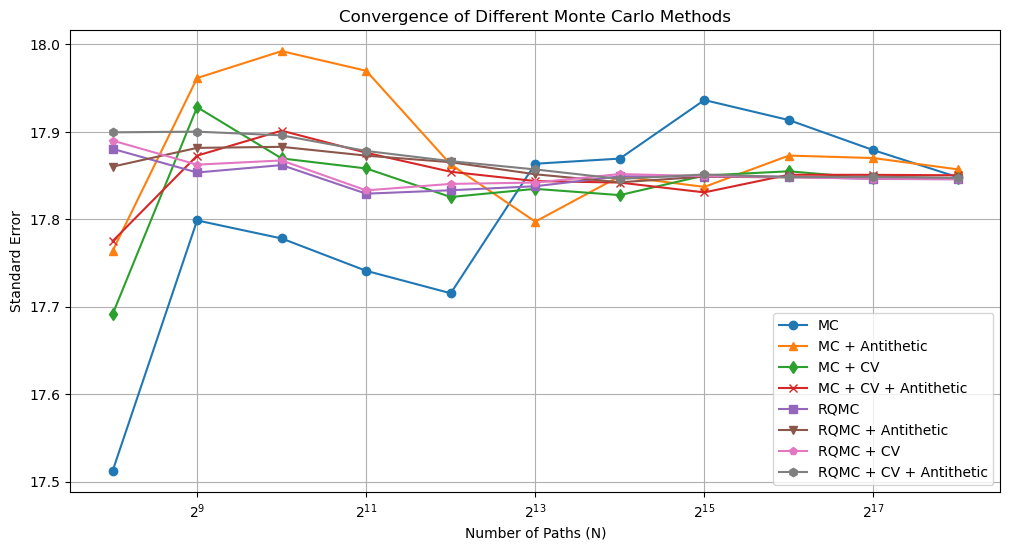

In [8]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(N_values, prices_mc, 'o-', label='MC')
plt.plot(N_values, prices_mc_ant, '^-', label='MC + Antithetic')
plt.plot(N_values, prices_mc_cv, 'd-', label='MC + CV')
plt.plot(N_values, prices_mc_cv_ant, 'x-', label='MC + CV + Antithetic')
plt.plot(N_values, prices_qmc, 's-', label='RQMC')
plt.plot(N_values, prices_qmc_ant, 'v-', label='RQMC + Antithetic')
plt.plot(N_values, prices_qmc_cv, 'p-', label='RQMC + CV')
plt.plot(N_values, prices_qmc_cv_ant, 'h-', label='RQMC + CV + Antithetic')
plt.grid(True)
plt.xscale('log', base=2)
#plt.yscale('log')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Different Monte Carlo Methods')
plt.legend()
plt.savefig(os.path.join(out_dir, 'All_convergence.png'), dpi=150)
plt.show()

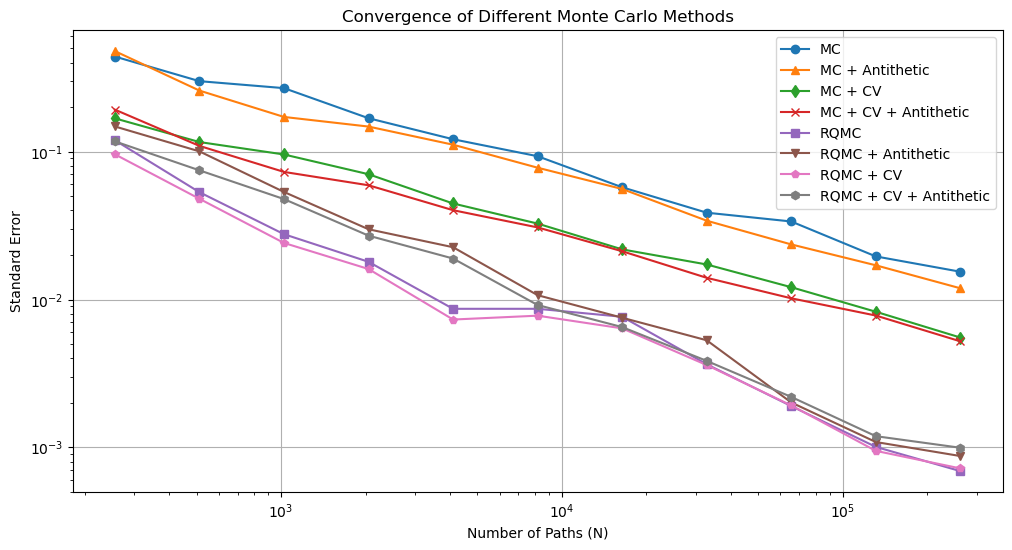

In [9]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(N_values, errors_mc, 'o-', label='MC')
plt.plot(N_values, errors_mc_ant, '^-', label='MC + Antithetic')
plt.plot(N_values, errors_mc_cv, 'd-', label='MC + CV')
plt.plot(N_values, errors_mc_cv_ant, 'x-', label='MC + CV + Antithetic')
plt.plot(N_values, errors_qmc, 's-', label='RQMC')
plt.plot(N_values, errors_qmc_ant, 'v-', label='RQMC + Antithetic')
plt.plot(N_values, errors_qmc_cv, 'p-', label='RQMC + CV')
plt.plot(N_values, errors_qmc_cv_ant, 'h-', label='RQMC + CV + Antithetic')
plt.grid(True)
plt.xscale('log', base=10)
plt.yscale('log')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Different Monte Carlo Methods')
plt.legend()
plt.savefig(os.path.join(out_dir, 'All_convergence.png'), dpi=150)
plt.show()

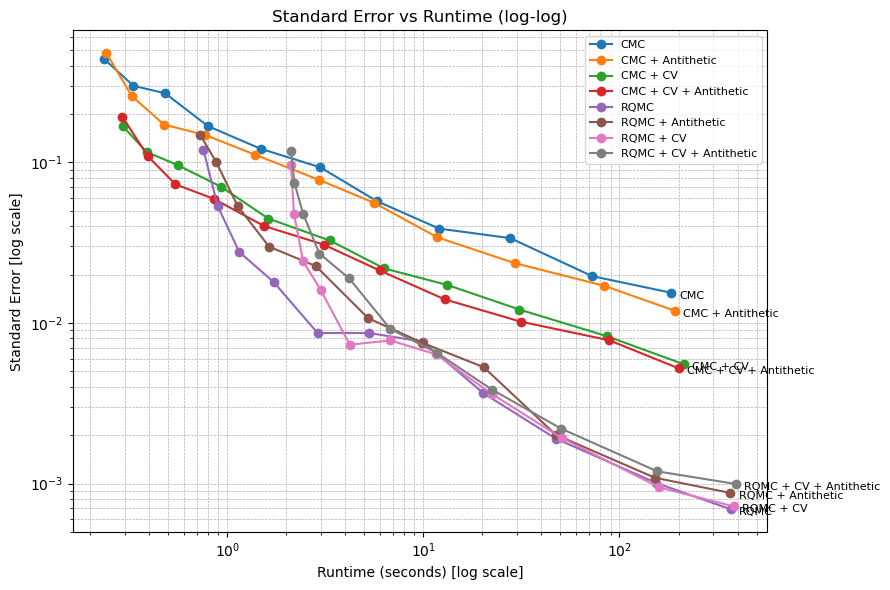

In [10]:
# Plot Standard Error vs Runtime (log-log)
fig, ax = plt.subplots(figsize=(9,6))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (label, prices, times, errs) in enumerate(methods):
    times_arr = np.array(times, dtype=float)
    errs_arr = np.array(errs, dtype=float)
    ax.plot(times_arr, errs_arr, marker='o', linestyle='-', label=label, color=colors[i % len(colors)])
    ax.annotate(label, xy=(times_arr[-1], errs_arr[-1]), xytext=(6, -2),
                textcoords='offset points', fontsize=8, va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Runtime (seconds) [log scale]')
ax.set_ylabel('Standard Error [log scale]')
ax.set_title('Standard Error vs Runtime (log-log)')
ax.grid(True, which='both', ls='--', lw=0.5)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, 'SE_vs_runtime.png'), dpi=150)
plt.show()

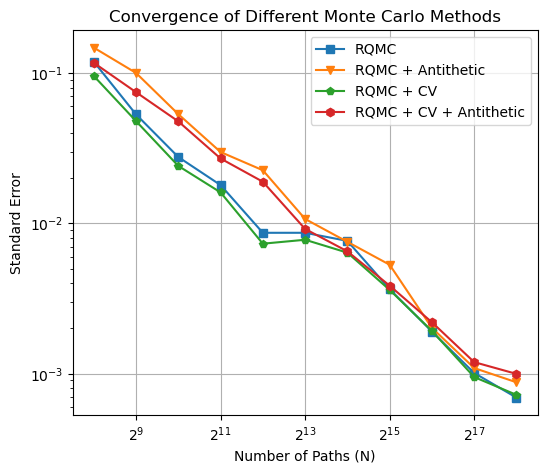

In [11]:
plt.figure(figsize=(6,5))
plt.plot(N_values, errors_qmc, 's-', label='RQMC')
plt.plot(N_values, errors_qmc_ant, 'v-', label='RQMC + Antithetic')
plt.plot(N_values, errors_qmc_cv, 'p-', label='RQMC + CV')
plt.plot(N_values, errors_qmc_cv_ant, 'h-', label='RQMC + CV + Antithetic')
plt.grid(True)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Number of Paths (N)')
plt.ylabel('Standard Error')
plt.title('Convergence of Different Monte Carlo Methods')
plt.legend()
plt.savefig(os.path.join(out_dir, 'All_convergence.png'), dpi=150)
plt.show()

In [12]:
# Build stacked table with rows grouped by N then Method 
rows = []
for idx, N in enumerate(N_values):
    for name, prices, times, errs in methods:
        price = float(prices[idx])
        se = float(errs[idx])
        t = float(times[idx])
        # VRF = variance_MC / variance_method = (SE_MC^2) / (SE_method^2)
        vrf = (errors_mc[idx] ** 2) / (se ** 2)
        if not np.isfinite(vrf):
            vrf = np.nan
        rows.append({'N': N, 'Method': name, 'Price': price, 'SE': se, 'Time(s)': t, 'VRF_vs_MC': vrf})

df_stacked = pd.DataFrame(rows).set_index(['N', 'Method']).sort_index()
df_stacked = df_stacked.round(8)

# Efficiency-at-largest-N summary 
rows_eff = []
for name, prices, times, errs in methods:
    se_last = float(np.array(errs, dtype=float)[-1])
    t_last = float(np.array(times, dtype=float)[-1])
    eff_last = (se_last ** 2) * t_last
    rows_eff.append({'Method': name, 'Eff_last': eff_last})
df_eff = pd.DataFrame(rows_eff).set_index('Method')
df_eff['Eff_rel_to_CMC'] = df_eff['Eff_last'] / df_eff.loc['CMC', 'Eff_last']
df_eff = df_eff.round(8)

# Save tables
csv_path_stacked = os.path.join(dir_Tables, 'results_by_N_stacked.tex')
csv_path_eff = os.path.join(dir_Tables, 'results_eff_at_largest_N.tex')
df_stacked.to_latex(csv_path_stacked)
df_eff.to_latex(csv_path_eff)

df_stacked


Price        SE     Time(s)   VRF_vs_MC
N      Method                                                             
256    CMC                     17.511980  0.438828    0.236038    1.000000
       CMC + Antithetic        17.763656  0.477567    0.242524    0.844345
       CMC + CV                17.691233  0.167707    0.293620    6.846767
       CMC + CV + Antithetic   17.774938  0.192067    0.292105    5.220184
       RQMC                    17.880562  0.119211    0.757158   13.550534
...                                  ...       ...         ...         ...
262144 CMC + CV + Antithetic   17.850307  0.005216  200.130336    8.726631
       RQMC                    17.845849  0.000692  369.520640  496.278945
       RQMC + Antithetic       17.847102  0.000875  367.602327  310.315414
       RQMC + CV               17.845756  0.000721  381.727084  456.076217
       RQMC + CV + Antithetic  17.847267  0.000995  390.517722  239.818669

[88 rows x 4 columns]

In [13]:
print("df_eff")

df_eff
